In [2]:
import pandas as pd
import numpy as np

# carico dataset normale
df = pd.read_pickle("D:/dataset_M1_M20_30_08_2026.pkl")

# carico dataset sanity check

df_sc = pd.read_pickle("D:/dataset_M1_M20_30_08_2026_sanity_check.pkl")


In [3]:
# label matrici
main_matrix_ids = []
for i in range(1,21):
    name_m = 'M' + str(i)
    main_matrix_ids.append(name_m)

### calcolo le distanze per il primo caso

In [17]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp[(SpineType, mm, 'experiment')] = aus_distances


In [18]:
spine_types = ['BLA', 'CA3']
# main_matrix_ids = ['mm3'] # , 'mm4', 'mm5', 'mm6', 'mm7']

cond = ['random']
# spine_types
# main_matrix_ids
distances_sim = {}
ref_Vs = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim[(SpineType, mm, 'random')] = aus_distances


### Calcolo delle distanze per il sanity check

In [19]:
distances_exp_sc = {}
ref_Vs_sc = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df_sc.loc[
            (df_sc["spine_type"] == SpineType) &
            (df_sc["main_matrix_id"] == mm) &
            (df_sc["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs_sc[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp_sc[(SpineType, mm, 'experiment')] = aus_distances


In [20]:

distances_sim_sc = {}
ref_Vs_sc = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df_sc.loc[
            (df_sc["spine_type"] == SpineType) &
            (df_sc["main_matrix_id"] == mm) &
            (df_sc["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs_sc[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs_sc[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim_sc[(SpineType, mm, 'random')] = aus_distances


In [72]:
#distances_sim_sc

In [21]:
# aggiunte 04 09 2026
regions =  ['BLA', 'CA3']
all_mms = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
for i in range(1,21):
    id = str(i)
    m_id = 'M' + id
    all_mms.append(m_id)

dati = {}
x0 = 1.0
dist_norm = {}
dist_norm_sc = {}
kde = {}
for i, mm in enumerate(all_mms):
    for j, region in enumerate(regions):

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

        # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        #d_exp = exp_data / mu
        d_exp = exp_data/ mu

        # ----- sanity check
        random_data_sc = np.array(
            distances_sim_sc[region, mm, 'random']
        )
        exp_data_sc = np.array(
            distances_exp_sc[region, mm, 'experiment']
        )

        # media random
        mu_sc = np.mean(random_data_sc)

        # normalizzazione
        d_sim_sc = random_data_sc / mu_sc
        #d_exp = exp_data / mu
        d_exp_sc = exp_data_sc/ mu_sc




        #dist_norm
        dist_norm[region, mm,'random'] = d_sim
        dist_norm[region,mm,'experiment'] = d_exp # shift_multiplo_da_dati(x0,d_exp)
        #dist_norm
        dist_norm_sc[region, mm,'random'] = d_sim_sc
        dist_norm_sc[region,mm,'experiment'] = d_exp_sc # shift_multiplo_da_dati(x0,d_exp)


In [45]:
dist_norm_sc['BLA', 'M1','experiment']


array([0.9161786 , 0.92373811, 1.04954521, 0.97773484, 1.01862233,
       0.94302665, 0.97507407, 0.94808761, 1.08185544, 1.03749073,
       0.9792307 , 1.02603083, 0.95698274, 1.03790033, 0.99498862,
       0.96452729, 1.02915787, 1.0545008 , 0.961688  , 1.04634452,
       1.01934426, 1.04545522, 1.01647055, 0.95409302, 1.03877369,
       1.04489039, 1.00179478, 0.99549586, 0.96363277, 1.04039409,
       0.96147791, 0.91401361, 1.05915131, 1.03257932, 1.01087164,
       1.02116712, 1.05213138, 1.07825239, 1.02435611, 1.08099163,
       0.95914068, 0.98779827, 0.98985383, 1.01006145, 0.96515693,
       1.04354027, 0.94586092, 0.92378079])

In [22]:
"""
Lo shift lo definisco come posizione del picco della KDE
"""
from scipy.stats import gaussian_kde

def picco_kde_da_dati(dati, n_punti_valutazione=5000):
    """
    Calcolo la KDE dei dati come in seaborn e trovo la posizione del suo picco
    n_punti_valutazione ---> Risoluzione della griglia su cui si valuta la KDE: piu' punti = stima del picco piu' precisa.
    """
    dati = np.asarray(dati)
    kde = gaussian_kde(dati) # ----- kde

    # Griglia di valutazione
    margine = 0.1 * (dati.max() - dati.min())
    x_grid = np.linspace(dati.min() - margine, dati.max() + margine, n_punti_valutazione)
    y_grid = kde(x_grid)

    x_picco = x_grid[np.argmax(y_grid)] # ----- posizione del picco della curva

    return x_picco, kde,x_grid




In [41]:
distr = {}
conditions = ['experiment', 'random']
risultati = {}
risultati_sc = {}
x0 = 1.0
for (area, matrice, condition), dn in dist_norm.items():

    name = f'{area}_{matrice}_{condition}'
    #distr[name] = dn
    risultati[area,matrice,condition] = picco_kde_da_dati(dn)


risultati.keys()

for (area, matrice, condition), dn in dist_norm_sc.items():

    name = f'{area}_{matrice}_{condition}'
    #distr[name] = dn
    risultati_sc[area,matrice,condition] = picco_kde_da_dati(dn)



risultati_sc['BLA','M1','random']


(np.float64(0.9988466413960755),
 array([0.81151183, 0.81157759, 0.81164334, ..., 1.14008749, 1.14015324,
        1.140219  ], shape=(5000,)))

In [44]:
risultati_sc['BLA','M1','experiment'][0]

np.float64(1.031878932758171)

In [43]:
shift_BLA = {}
shift_CA3 = {}

shift_BLA_sc = {}
shift_CA3_sc = {}

for i in range(1,21):
    matrix_name = 'M' + str(i)
    shift_BLA['BLA',matrix_name] = risultati['BLA',matrix_name,'experiment'][0] - risultati['BLA',matrix_name,'random'][0]
    shift_CA3['CA3', matrix_name] = risultati['CA3',matrix_name,'experiment'][0] - risultati['CA3', matrix_name,'random'][0]

    shift_BLA_sc['BLA',matrix_name] = risultati_sc['BLA',matrix_name,'experiment'][0] - risultati_sc['BLA',matrix_name,'random'][0]
    shift_CA3_sc['CA3', matrix_name] = risultati_sc['CA3',matrix_name,'experiment'][0] - risultati_sc['CA3', matrix_name,'random'][0]


print(shift_BLA_sc)

{('BLA', 'M1'): np.float64(0.03303229136209551), ('BLA', 'M2'): np.float64(-0.024934185129977693), ('BLA', 'M3'): np.float64(0.009991540200421034), ('BLA', 'M4'): np.float64(0.05145169676460859), ('BLA', 'M5'): np.float64(-0.02212777979297942), ('BLA', 'M6'): np.float64(0.009500271925243275), ('BLA', 'M7'): np.float64(0.0038980262366345997), ('BLA', 'M8'): np.float64(0.00036713509419294965), ('BLA', 'M9'): np.float64(-0.021503730999689386), ('BLA', 'M10'): np.float64(-0.0021789002668006763), ('BLA', 'M11'): np.float64(0.01868762040949523), ('BLA', 'M12'): np.float64(-0.032164169060032166), ('BLA', 'M13'): np.float64(-0.023525519730781985), ('BLA', 'M14'): np.float64(0.013759363164298044), ('BLA', 'M15'): np.float64(-0.025310791653067266), ('BLA', 'M16'): np.float64(0.006909259930397038), ('BLA', 'M17'): np.float64(0.007400066388329796), ('BLA', 'M18'): np.float64(-0.007290347920756002), ('BLA', 'M19'): np.float64(0.0887607340404235), ('BLA', 'M20'): np.float64(-0.045678200599405416)}


#### Plot per ogni Main matrix di (shift_BLA, shift_CA3)

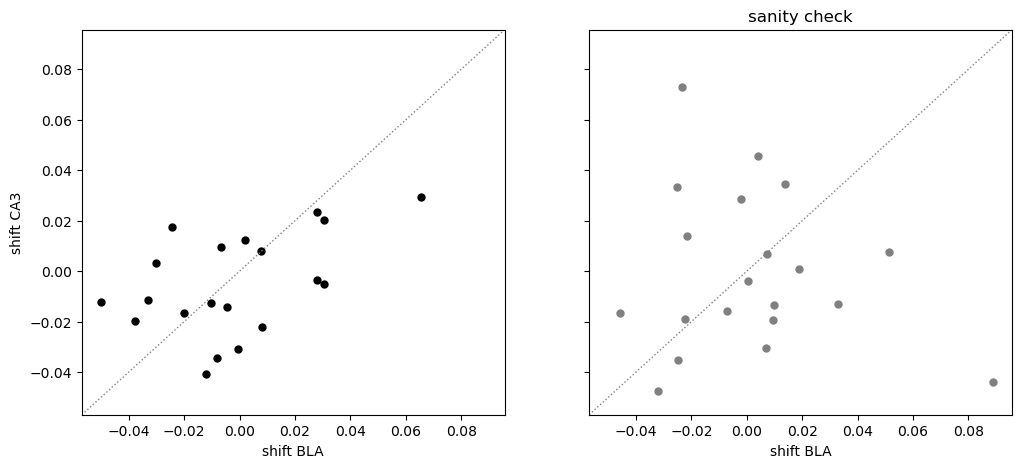

In [68]:
#plt.figure(figursize= (10,10))
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,5),sharey=True,sharex=True)
#print(all_mms)
for m in all_mms:
    x = shift_BLA['BLA',m]
    y  = shift_CA3['CA3',m]

    x_sc = shift_BLA_sc['BLA',m]
    y_sc = shift_CA3_sc['CA3',m]

    #if m in ['M1', 'M4', 'M6','M11','M14','M17','M7']:
    #    mark = '>'
    #elif m in ['M2', 'M3', 'M9', 'M15', 'M16', 'M18','M10']:
    #    mark = '<'
    #else:
    #    mark = '.'
    #plt.plot(x,y,mark,label=m)
    axes[0].plot(x,y,'.k',markersize=10)
    axes[1].plot(x_sc,y_sc,'.',color='grey',markersize=10)

axes[1].set_title('sanity check')
axes[0].set_xlabel('shift BLA')
axes[1].set_xlabel('shift BLA')
axes[0].set_ylabel('shift CA3')

for ax in axes:
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        color='gray',
        linestyle=':',
        linewidth=1
    )

    # stessi limiti su x e y
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

'''
ax = plt.gca()
lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color='gray', linewidth=0.8, linestyle=':', label='y = x')
plt.title('Main matrix id')
plt.xlabel('shift BLA')
plt.ylabel('shift CA3')
#plt.legend()
'''
plt.show()

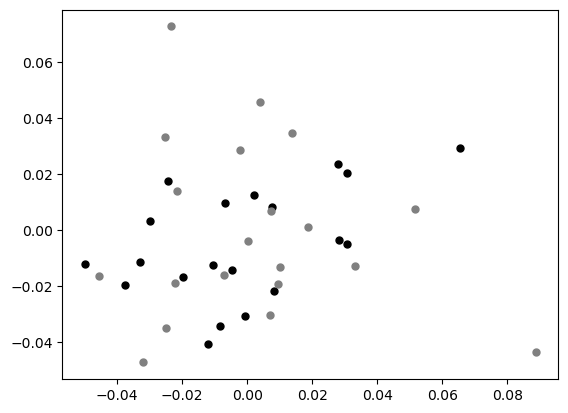

In [71]:
for m in all_mms:
    x = shift_BLA['BLA',m]
    y  = shift_CA3['CA3',m]

    x_sc = shift_BLA_sc['BLA',m]
    y_sc = shift_CA3_sc['CA3',m]
    plt.plot(x,y,'.k',markersize=10)
    plt.plot(x_sc,y_sc,'.',color='grey',markersize=10)